#### Conditional Steering:
    Identifying neurons that write some target concept to the residual stream on a specific data distribution. Then boosting or suppressing the neuron activations to alter the way it acts on the distribution.

#### Algorithm:
    > Use DLA to identify the layer (optional: to narrow down the search space) 
    > Search for neurons that can write our target concept into the residual stream
        > Data Driven:
            - collect a high variance data distribution of text sequences contatining *target tokne*
            - run inference and collect SAE neuron activations at the *target token*
            - calculate the mean activation value of every neuron at *target token* and get the top neurons
    > Intervene on the output of our target neuron, by boosting or suppressing its activations with
      a constant value.

### Imports and Preferences 

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os

import torch
from torch import Tensor, nn
import torch.nn.functional as F
from tabulate import tabulate
import numpy
import matplotlib.pyplot as plt
import random
from pprint import pprint
import einops
from einops import einsum
import seaborn as sns
from functools import partial

from typing import Any, Callable, Literal, TypeAlias
from jaxtyping import Float, Int

from IPython.display import HTML, IFrame, display
from datasets import load_dataset
from huggingface_hub import hf_hub_download

import circuitsvis as cv
import plotly.express as px
import sae_lens
from sae_lens import SAE, ActivationsStore, HookedSAETransformer, LanguageModelSAERunnerConfig
from sae_lens.loading.pretrained_saes_directory import get_pretrained_saes_directory

from torch.nn import functional as F
from tqdm.auto import tqdm
from transformer_lens import ActivationCache, HookedTransformer
from transformer_lens.hook_points import HookPoint
from transformer_lens.utils import get_act_name, test_prompt, to_numpy

from rich import print as rprint
from rich.table import Table

from neuronpedia_utils import display_dashboard
from interp_utils import SAEStore
from interp_utils import (
    get_layer_attributions,
    decomposed_head_attribs,
    show_token_scores,
    show_topk_preds,
    display_max_activating_examples,
)
from plot_utils import (
    get_and_visualize_model_attributions,
    get_and_visualize_head_attributions,
    visualize_transformer_attributions,
    visualize_head_attributions,
    visualize_attention_pattern,
)
from data_support import clown_hate, clown_normal   # text seqs contatining expression of hate towards clowns

In [4]:
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

### Setting-Up HookedSAETransformer and SAEStore

In [5]:
sae_model: HookedSAETransformer = HookedSAETransformer.from_pretrained("gpt2-small")

release_name = "gpt2-small-res-jb"
sae_store = SAEStore(release_name=release_name, use_error_term=True, device="cuda")

sae_keys = list(sae_store.sae_dict.keys())
sae_cfg = list(sae_store.sae_dict.values())[0]['cfg']

Loaded pretrained model gpt2-small into HookedTransformer


loading saes:   0%|          | 0/13 [00:00<?, ?it/s]

/home/happyinterp/miniconda3/envs/mech-interp/lib/python3.11/site-packages/sae_lens/saes/sae.py:249: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(


In [6]:
# cut sequence after ' clown' token

clown_hate_cut, clown_norm_cut = [], []
for hate_sample, norm_sample in zip(clown_hate, clown_normal):
    till_clown_hate, till_clown_norm = [], []
    for token in sae_model.to_str_tokens(hate_sample):
        till_clown_hate.append(token)
        if token == " clown":
            clown_hate_cut.append("".join(till_clown_hate[1:]))
            break
    for token in sae_model.to_str_tokens(norm_sample):
        till_clown_norm.append(token)
        if token == " clown":
            clown_norm_cut.append("".join(till_clown_norm[1:]))
            break

print(f"HATE CLOWN CUT: \n{clown_hate_cut[:3]}\n")
print(f"NORMAL CLOWN CUT: \n{clown_norm_cut[:3]}")

HATE CLOWN CUT: 
['people started to hate the entire creepy vibe of that clown', 'many adults quietly hate the exaggerated makeup and behavior of a clown', 'some viewers grow to hate the unsettling presence of a clown']

NORMAL CLOWN CUT: 
['at the birthday party the children gathered around a cheerful clown', 'during the parade people lined the street to watch a tall clown', 'inside the circus tent the audience waited for a juggling clown']


### Identifying Most Contributing Layers

In [7]:
test_sample = clown_hate_cut[3][:-6]   # some test sequence
target_id = sae_model.to_single_token(" clown")

print(test_sample, "\n\nTop predictions:")
show_topk_preds(model=sae_model, prompt=test_sample, k=5)
print("\nTarget token scores:")
show_token_scores(model=sae_model, prompt=test_sample, target_id=target_id)

# Rank of " clown" for every sample
# for sample in clown_hate_cut:
#     show_token_scores(model=sae_model, prompt=sample[:-6], target_id=target_id)

my friends began to hate the loud costume and forced laughter of a 

Top predictions:
PROB: 40.26%  TOKEN: | few|
PROB: 19.46%  TOKEN: | group|
PROB: 16.36%  TOKEN: | bunch|
PROB: 12.39%  TOKEN: | young|
PROB: 11.53%  TOKEN: | man|

Target token scores:
TOKEN: | clown| RANK: 25, PROB: 0.004684695973992348


In [8]:
# get_and_visualize_model_attributions(
#     model=sae_model,
#     input_str=clown_hate_cut[4][:-6],
#     target_idx=target_id,
#     save_path=None,    # saved at ./results/conditional_steering_results/hate_clown.png
# )

In [9]:
# get_and_visualize_head_attributions(
#     model=sae_model,
#     input_str=test_sample,
#     target_idx=target_id,
#     figsize=(12, 4),
# )

In [10]:
_, cache = sae_model.run_with_cache(test_sample, remove_batch_dim=True)
print(torch.sort(get_layer_attributions(sae_model, typ="mlp", cache=cache, target_idx=target_id), descending=True))

torch.return_types.sort(
values=tensor([12.5522, 11.4797,  9.5731,  6.7029,  4.6256,  4.0970,  3.3717,  2.2528,
         0.7477, -0.1290, -0.6163, -0.8246]),
indices=tensor([10, 11,  9,  5,  7,  8,  6,  0,  2,  3,  1,  4]))


/home/happyinterp/main/3m/jupyter/llm-interp-practice/major-project/interp_utils.py:281: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  return torch.tensor(attrib_list)


In [11]:
get_layer_attributions(sae_model, "mlp", cache, target_id).detach().size()
decomposed_head_attribs(sae_model, cache, target_id).detach().size()

torch.Size([12, 12])

In [12]:
mean_mlp_attribs, mean_dcm_head_attribs = torch.zeros(12, device="cpu"), torch.zeros((12, 12), device="cpu")
samples = clown_norm_cut+clown_hate_cut

for sample in samples:
    _, cache = sae_model.run_with_cache(sample[:-6], remove_batch_dim=True)
    mean_mlp_attribs += get_layer_attributions(sae_model, "mlp", cache, target_id).detach().cpu()
    mean_dcm_head_attribs += decomposed_head_attribs(sae_model, cache, target_id).detach().cpu()

mean_mlp_attribs, mean_dcm_head_attribs = mean_mlp_attribs/len(samples), mean_dcm_head_attribs/len(samples)

In [13]:
# visualize_transformer_attributions(
#     head_attributions=mean_dcm_head_attribs,
#     mlp_attributions=mean_mlp_attribs,
#     input_token="hate_clown_seq",
#     output_token=sae_model.to_string(target_id),
#     save_path=None, 
# )
# # saved at ./results/conditional_steering_results/

# # Identified Outliers:
# # L9MLP, L10MLP, L11MLP
# # L9H3, L11H3

### MLP Layer Analysis

#### Weight Based

In [14]:
# weight based " clown" token writer search

sae_model.W_U.size()
sae_11_w_dec = sae_store.sae_dict[sae_keys[11]]["sae"].W_dec
sae_11_clown_writers = F.cosine_similarity(sae_11_w_dec, sae_model.W_U.T[target_id])

In [15]:
top_clown_sims, top_clown_ids = torch.topk(sae_11_clown_writers, k=5)
print("Neuron | Cosine Sim \n-------------------")
for top_clown_sim, top_clown_id in zip(top_clown_sims, top_clown_ids):
    print(f"{str(int(top_clown_id)):<6} |   {float(top_clown_sim):.3f}")

Neuron | Cosine Sim 
-------------------
2652   |   0.309
9875   |   0.255
458    |   0.239
19778  |   0.239
12836  |   0.232


#### Identifying ' hate' neuron

In [44]:
mlp_layers = [11, 10, 9]    # based on logit attributions

mean_acts_hate = sae_store.mean_sae_decoder_activation(
    sae_model=sae_model,
    samples=clown_hate,
    target_id=sae_model.to_single_token(" hate"),
    layers=mlp_layers,
    pre_target=False,
)

In [45]:
# most active neurons in 'mlp_layers' on hate_clown_cut data at pre_traget index

k = 10
top_active_neurons_dict = {layer: None for layer in mlp_layers}
for i in range(mean_acts_hate.size()[0]):
    top_active_neurons_dict[11-i] = torch.topk(mean_acts_hate[i], k=k)

In [49]:
# 13458 - activates to " love" and " hate"
# 6707  - activates to " hate"

top_active_neurons_dict[11]

torch.return_types.topk(
values=tensor([27.1835, 27.1770, 15.4220,  8.9742,  8.9400,  7.7671,  7.6891,  7.4179,
         7.3655,  6.3909], device='cuda:0'),
indices=tensor([16996, 13458,  6707, 21308, 14364, 10401,  7055,  8698,  1803, 23893],
       device='cuda:0'))

#### Steering Neuron 6707

In [ ]:
# acts[:, -1, neuron_id] @ sae_model.

In [51]:
import torch
from contextlib import contextmanager

@contextmanager
def steer_sae_decoder_row(
    sae,
    sae_model,
    neuron_id: int,
    target_token_id: int,
    alpha: float,
    norm_preserve: bool = True,
):
    with torch.no_grad():
        # --- Save original row ---
        original_row = sae.W_dec[neuron_id, :].clone()

        # --- Get unembedding vector ---
        W_U = sae_model.W_U
        d_model = sae_model.cfg.d_model

        if W_U.shape[0] == d_model:
            # [d_model, vocab]
            target_vec = W_U[:, target_token_id]
        else:
            # [vocab, d_model]
            target_vec = W_U[target_token_id, :]

        target_vec = target_vec.to(original_row.device)

        # --- Interpolate ---
        new_row = (1 - alpha) * original_row + alpha * target_vec

        # --- Optional norm preservation ---
        if norm_preserve:
            orig_norm = original_row.norm()
            new_row = new_row * (orig_norm / (new_row.norm() + 1e-8))

        # --- Apply edit ---
        sae.W_dec[neuron_id, :] = new_row

    try:
        yield
    finally:
        # --- Restore original weights ---
        with torch.no_grad():
            sae.W_dec[neuron_id, :] = original_row


In [11]:
attn_pattern_names_filter = [f"blocks.{i}.attn.hook_pattern" for i in range(sae_model.cfg.n_heads)]
_, attn_pattern_cache = sae_model.run_with_cache(
    [sample[:-6] for sample in clown_hate_cut],
    names_filter=attn_pattern_names_filter,
)

In [13]:
clown_hate_cut[3][:-6]

'my friends began to hate the loud costume and forced laughter of a'

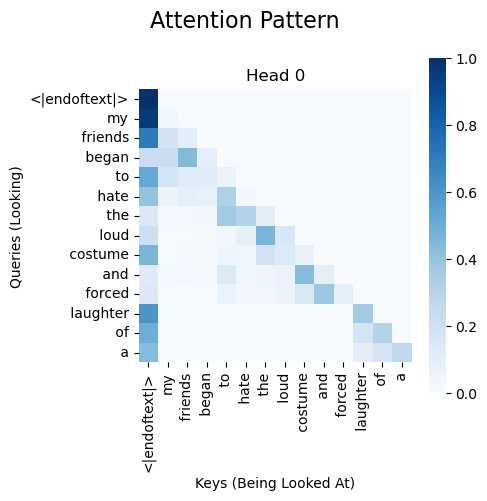

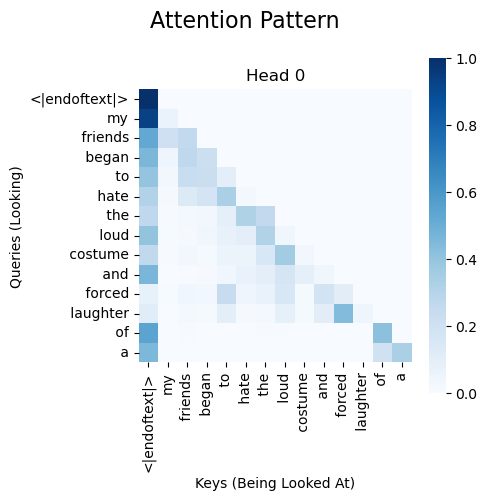

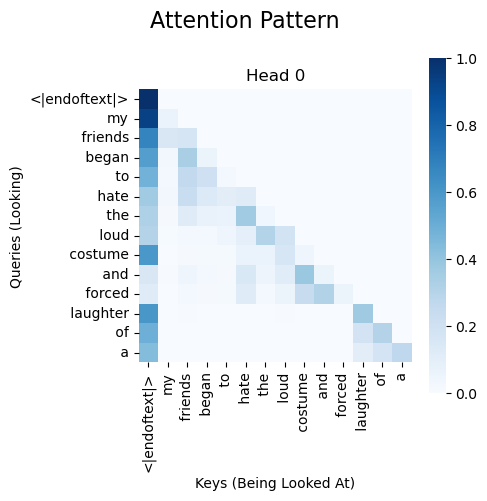

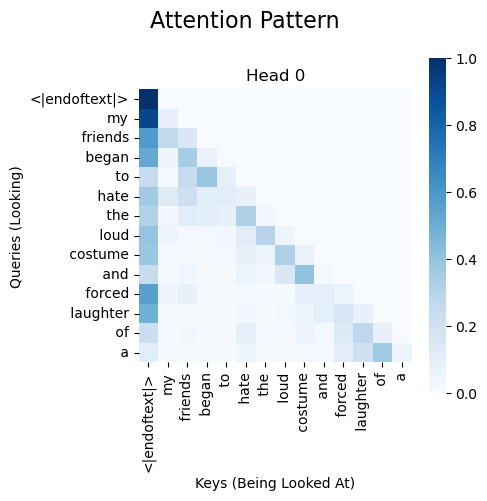

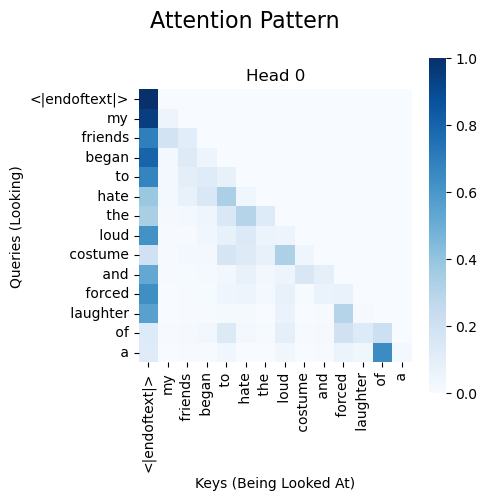

In [15]:
seq_idx, layer, head = 3, 9, 3

for seq_idx in range(5):
    attention_pattern = attn_pattern_cache[attn_pattern_names_filter[layer]][seq_idx, head, :, :]
    visualize_attention_pattern(tokens=sae_model.to_str_tokens(test_sample), attention=attention_pattern)

In [72]:
sae11 = sae_store.get_sae_list(item="sae")[11]

with steer_sae_decoder_row(
    sae=sae11,
    sae_model=sae_model,
    neuron_id=6707,        # hate feature
    target_token_id=sae_model.to_single_token(" clown"),
    alpha=0.4,
):
    logits_mod, cache_mod = sae_model.run_with_cache_with_saes(
        clown_hate_cut[4],
        saes=[sae11]
    )

logits_clean, cache_clean = sae_model.run_with_cache_with_saes(
    clown_hate_cut[4]
)

In [78]:
clown_hate_cut[4]

'audiences often hate the forced enthusiasm and awkward jokes coming from a clown'

In [81]:
def show_token_scores_from_logits(model, logits, target_id):
    probs = torch.softmax(logits[0, -3, :], dim=-1)
    
    target_prob = probs[target_id].item()
    
    sorted_probs, sorted_indices = torch.sort(probs, descending=True)
    rank = (sorted_indices == target_id).nonzero(as_tuple=True)[0].item() + 1

    print(f"TOKEN: |{model.to_single_str_token(target_id)}| RANK: {rank}, PROB: {target_prob}")

In [82]:
show_token_scores_from_logits(model=sae_model, logits=logits_clean, target_id=target_id)
show_token_scores_from_logits(model=sae_model, logits=logits_mod, target_id=target_id)

TOKEN: | clown| RANK: 757, PROB: 0.00013242918066680431
TOKEN: | clown| RANK: 757, PROB: 0.00013242910790722817
